In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("data.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [ ]:
print(df.shape)

(294, 14)


In [ ]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num       '],
      dtype='object')


In [ ]:
print(df.dtypes)

age             int64
sex             int64
cp              int64
trestbps       object
chol           object
fbs            object
restecg        object
thalach        object
exang          object
oldpeak       float64
slope          object
ca             object
thal           object
num             int64
dtype: object


In [ ]:
print(df.isnull().sum())

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
num           0
dtype: int64


In [ ]:
print((df.isnull().sum()/len(df))*100)

age           0.0
sex           0.0
cp            0.0
trestbps      0.0
chol          0.0
fbs           0.0
restecg       0.0
thalach       0.0
exang         0.0
oldpeak       0.0
slope         0.0
ca            0.0
thal          0.0
num           0.0
dtype: float64


In [ ]:
print(df.describe())

              age         sex          cp     oldpeak  num       
count  294.000000  294.000000  294.000000  294.000000  294.000000
mean    47.826531    0.724490    2.982993    0.586054    0.360544
std      7.811812    0.447533    0.965117    0.908648    0.480977
min     28.000000    0.000000    1.000000    0.000000    0.000000
25%     42.000000    0.000000    2.000000    0.000000    0.000000
50%     49.000000    1.000000    3.000000    0.000000    0.000000
75%     54.000000    1.000000    4.000000    1.000000    1.000000
max     66.000000    1.000000    4.000000    5.000000    1.000000


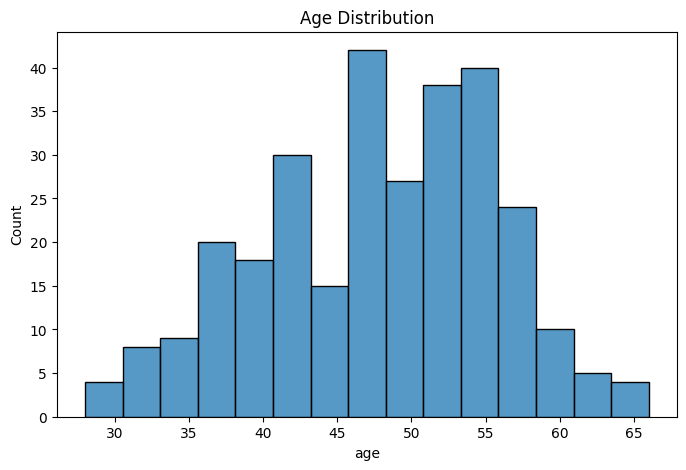

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=15)
plt.title("Age Distribution")
plt.show()

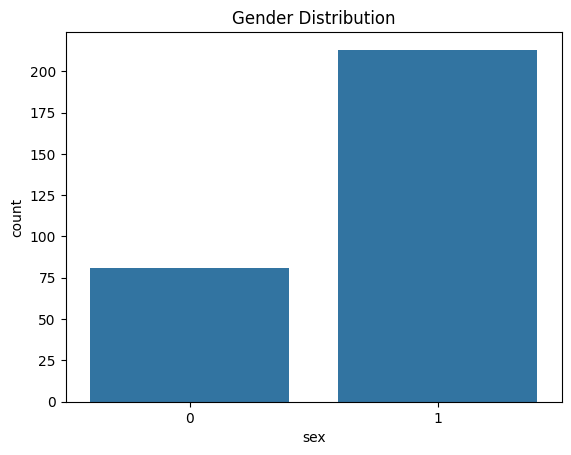

In [ ]:
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

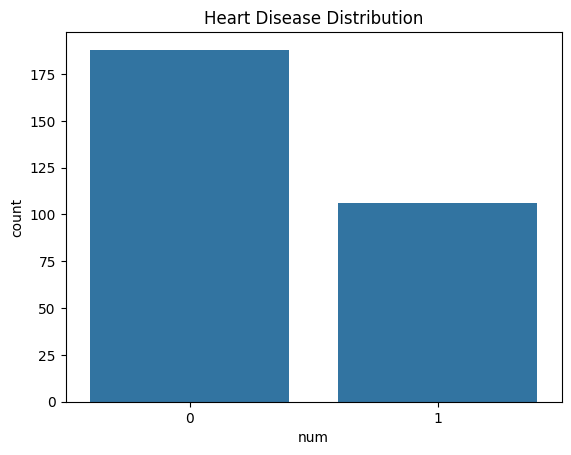

In [ ]:
df.columns = df.columns.str.strip()
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

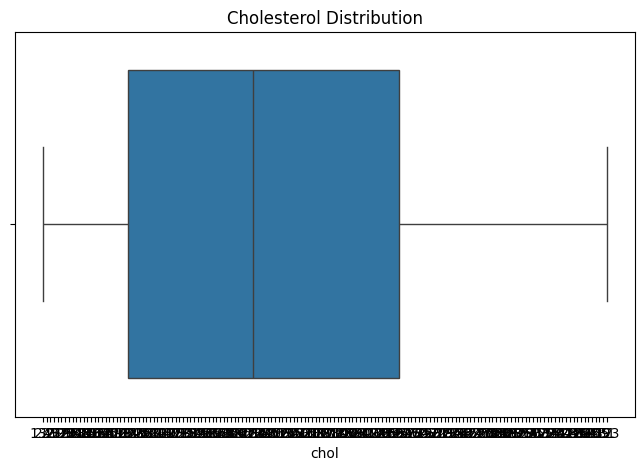

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['chol'])
plt.title("Cholesterol Distribution")
plt.show()

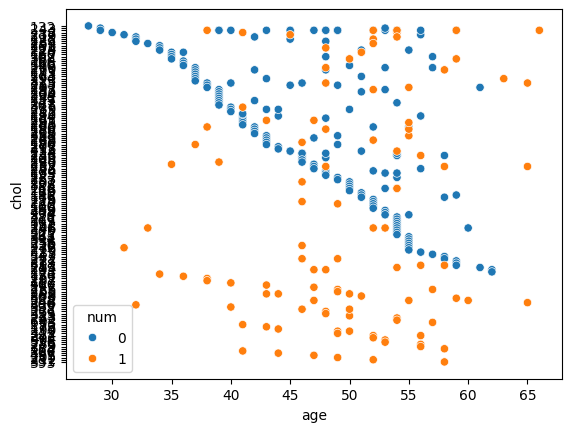

In [ ]:
sns.scatterplot(x='age', y='chol', hue='num', data=df)
plt.show()

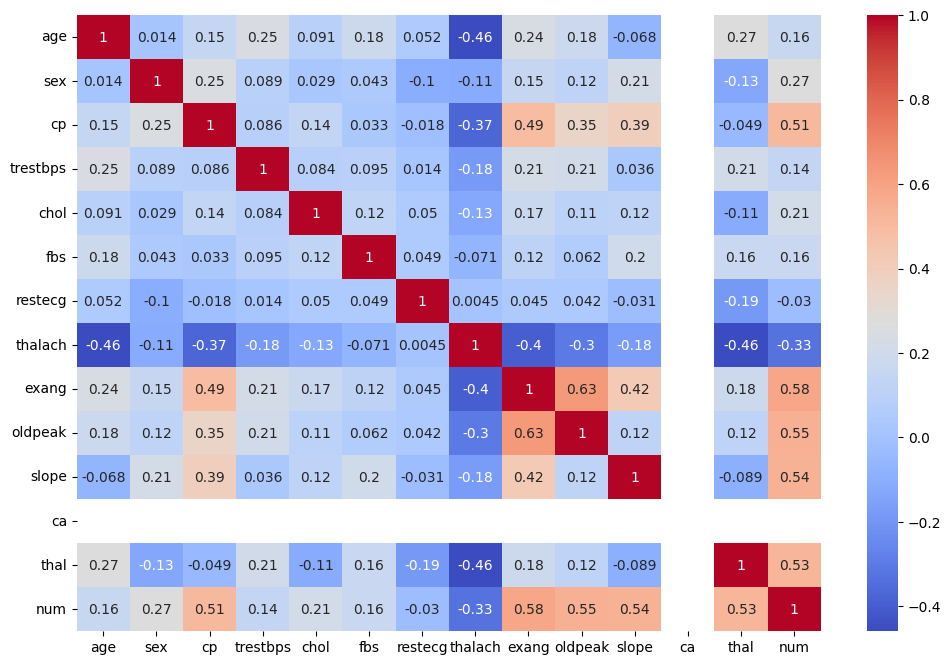

In [ ]:
for col in ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca', 'thal']:
    df[col] = df[col].replace('?', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

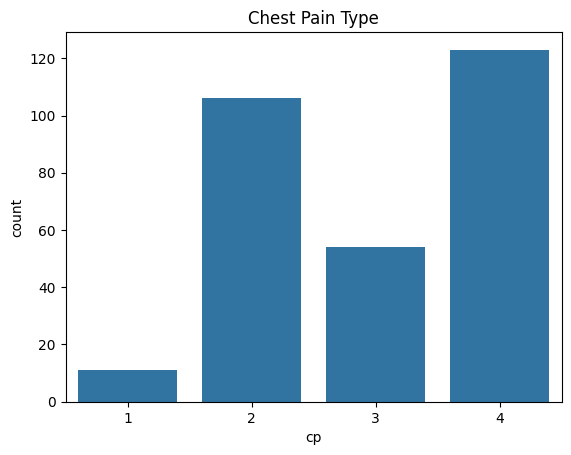

In [ ]:
sns.countplot(x='cp', data=df)
plt.title("Chest Pain Type")
plt.show()

In [ ]:
X = df.drop('num', axis=1)
y = df['num']

In [ ]:
X = X.fillna(X.mean())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8983050847457628


In [ ]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))

Accuracy: 0.7627118644067796


In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 0.8305084745762712


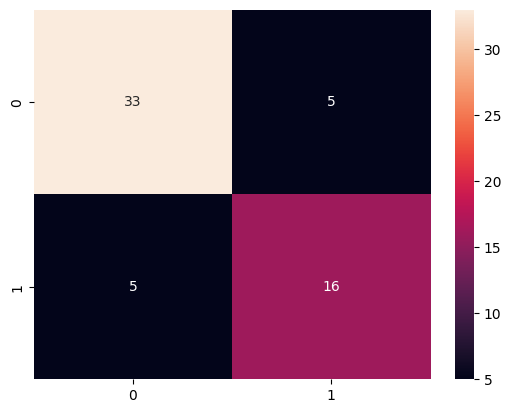

In [ ]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.show()

In [ ]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        38
           1       0.76      0.76      0.76        21

    accuracy                           0.83        59
   macro avg       0.82      0.82      0.82        59
weighted avg       0.83      0.83      0.83        59

